In [1]:
"""
========================================================
  PROJECT 4: Options Pricer (Black-Scholes)
========================================================
  Concepts covered:
    - What options are: calls and puts
    - The Black-Scholes formula for European options
    - The five inputs: S, K, T, r, σ
    - The Greeks: Delta, Gamma, Vega, Theta, Rho
    - Visualising how option price and Greeks change
      with spot price and time to expiry
    - Implied volatility (what vol does the market imply?)

  Builds on Projects 1–3:
    - σ is estimated from historical data (Project 1)
    - The log-normal assumption comes from GBM (Project 3)
    - Monte Carlo pricing of the same options is Project 5

  Requirements:
    pip install yfinance pandas numpy matplotlib scipy

  Usage:
    Edit CONFIG below, then run:
      python project4_black_scholes.py
========================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf

In [8]:
# ── Configuration ──────────────────────────────────────────────────────────────

#user inputted ticker
def get_valid_ticker(max_attempts=3, fallback="VOO"):
    for attempt in range(1, max_attempts + 1):
        raw_input = input(f"Enter a valid stock ticker: ")
        candidates = [t.strip().upper() for t in raw_input.split(",")][:4]

        # Validate ticker by trying to download a small amount of data
        data = yf.download(raw_input, period="5d", progress=False, auto_adjust=True)
        if not data.empty:
            print(f"  ✓ Ticker is valid: {raw_input}\n")
            return raw_input
        else:
            print(f"  ✗ Could not find data for: {raw_input}")
            if attempt < max_attempts:
                print(f"  Please try again with a valid ticker name. ({max_attempts - attempt} attempt(s) remaining)\n")
            else:
                print(f"  Max attempts reached. Running analysis on fallback ticker: {fallback}\n")
                return fallback
        

TICKER       = get_valid_ticker()
START_DATE   = "2023-01-01"
END_DATE     = "2026-01-01"
TRADING_DAYS = 252

# Option parameters — edit these to explore
S  = 180.0    # Current stock price ($)
K  = 180.0    # Strike price ($)       ← at-the-money by default
T  = 1.0      # Time to expiry (years) ← 1 year
tbill = yf.Ticker("^IRX") # 13-week (3-month) Treasury bill yield
r = tbill.fast_info["lastPrice"] / 100  # convert from percentage to decimal
σ  = 0.28     # Volatility (annual)    ← overwritten if yfinance available


Enter a valid stock ticker: AAPL
  ✓ Ticker is valid: AAPL



In [3]:
# ── Parameter Estimation ───────────────────────────────────────────────────────

def estimate_sigma(ticker: str, start: str, end: str) -> float:
    """Estimate annualised volatility from historical log returns."""
    raw        = yf.download(ticker, start=start, end=end,
                             auto_adjust=True, progress=False)
    prices     = raw["Close"].squeeze()
    log_ret    = np.log(prices / prices.shift(1)).dropna()
    sigma      = float(log_ret.std() * np.sqrt(TRADING_DAYS))
    spot       = float(prices.iloc[-1])
    print(f"  {ticker}: S0=${spot:.2f},  σ={sigma:.2%}  (from {start} to {end})\n")
    return sigma, spot


# ── Black-Scholes Core ─────────────────────────────────────────────────────────

def d1(S: float, K: float, T: float, r: float, sigma: float) -> float:
    """
    d1 is the first term inside the Normal CDF in the BS formula.

    Intuitively: d1 measures how far in-the-money the option is,
    adjusted for time, rate, and volatility. Larger d1 → deeper
    in-the-money → higher probability of finishing above the strike.

        d1 = [ln(S/K) + (r + ½σ²)T] / (σ√T)
    """
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


def d2(S: float, K: float, T: float, r: float, sigma: float) -> float:
    """
    d2 = d1 - σ√T

    N(d2) is the risk-neutral probability that the option expires
    in-the-money (i.e. S_T > K for a call).
    """
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)


def bs_call(S: float, K: float, T: float, r: float, sigma: float) -> float:
    """
    Black-Scholes price for a European CALL option.

        C = S·N(d1) - K·e^(-rT)·N(d2)

    Intuition:
      - S·N(d1)        : expected value of receiving the stock if S_T > K
      - K·e^(-rT)·N(d2): present value of paying the strike, weighted by
                         the probability of exercise
    """
    if T <= 0:
        return max(S - K, 0.0)
    _d1 = d1(S, K, T, r, sigma)
    _d2 = d2(S, K, T, r, sigma)
    return S * norm.cdf(_d1) - K * np.exp(-r * T) * norm.cdf(_d2)


def bs_put(S: float, K: float, T: float, r: float, sigma: float) -> float:
    """
    Black-Scholes price for a European PUT option.

        P = K·e^(-rT)·N(-d2) - S·N(-d1)

    Alternatively derived from Put-Call Parity:
        P = C - S + K·e^(-rT)

    Put-Call Parity is a model-free no-arbitrage relationship —
    it holds regardless of the pricing model used.
    """
    if T <= 0:
        return max(K - S, 0.0)
    _d1 = d1(S, K, T, r, sigma)
    _d2 = d2(S, K, T, r, sigma)
    return K * np.exp(-r * T) * norm.cdf(-_d2) - S * norm.cdf(-_d1)

In [4]:
# ── The Greeks ─────────────────────────────────────────────────────────────────
#
# The Greeks measure the sensitivity of an option's price to each input.
# They're the primary tool traders use to hedge and manage options risk.

def delta(S: float, K: float, T: float, r: float,
          sigma: float, option_type: str = "call") -> float:
    """
    Delta = ∂C/∂S  (how much the option price moves per $1 move in S)

    - Call delta: between 0 and 1
        → 0.5 at-the-money, approaches 1 deep in-the-money
    - Put delta: between -1 and 0
        → -0.5 at-the-money, approaches -1 deep in-the-money

    A delta of 0.6 means: if the stock rises $1, the call gains ~$0.60.
    Delta is also roughly the probability the option expires in-the-money.
    """
    if T <= 0:
        return 1.0 if (option_type == "call" and S > K) else 0.0
    _d1 = d1(S, K, T, r, sigma)
    if option_type == "call":
        return norm.cdf(_d1)
    return norm.cdf(_d1) - 1


def gamma(S: float, K: float, T: float, r: float, sigma: float) -> float:
    """
    Gamma = ∂²C/∂S²  (rate of change of delta)

    Gamma is the same for calls and puts (by put-call parity).
    High gamma means delta changes rapidly as the stock moves —
    the option's hedge ratio needs frequent updating.
    Gamma is highest for at-the-money options near expiry.
    """
    if T <= 0:
        return 0.0
    _d1 = d1(S, K, T, r, sigma)
    return norm.pdf(_d1) / (S * sigma * np.sqrt(T))


def vega(S: float, K: float, T: float, r: float, sigma: float) -> float:
    """
    Vega = ∂C/∂σ  (sensitivity to a 1% change in volatility)

    Vega is the same for calls and puts.
    High vega means the option is very sensitive to changes in
    implied volatility — relevant when trading around earnings or
    macro events that are expected to move vol.

    Reported per 1% change in σ (divide raw vega by 100).
    """
    if T <= 0:
        return 0.0
    _d1 = d1(S, K, T, r, sigma)
    return S * norm.pdf(_d1) * np.sqrt(T) / 100   # per 1% vol move


def theta(S: float, K: float, T: float, r: float,
          sigma: float, option_type: str = "call") -> float:
    """
    Theta = ∂C/∂T  (time decay — how much value the option loses per day)

    Theta is almost always negative for long options — you lose value
    every day just from time passing, all else equal. This is called
    'time decay' and is the option seller's friend.

    Reported per calendar day (divide by 365).
    """
    if T <= 0:
        return 0.0
    _d1 = d1(S, K, T, r, sigma)
    _d2 = d2(S, K, T, r, sigma)
    term1 = -(S * norm.pdf(_d1) * sigma) / (2 * np.sqrt(T))
    if option_type == "call":
        term2 = -r * K * np.exp(-r * T) * norm.cdf(_d2)
    else:
        term2 =  r * K * np.exp(-r * T) * norm.cdf(-_d2)
    return (term1 + term2) / 365   # per calendar day


def rho(S: float, K: float, T: float, r: float,
        sigma: float, option_type: str = "call") -> float:
    """
    Rho = ∂C/∂r  (sensitivity to interest rate changes)

    Calls have positive rho (higher rates → higher call value).
    Puts have negative rho (higher rates → lower put value).
    Rho matters most for long-dated options; less so for short-dated.

    Reported per 1% change in r.
    """
    if T <= 0:
        return 0.0
    _d2 = d2(S, K, T, r, sigma)
    if option_type == "call":
        return K * T * np.exp(-r * T) * norm.cdf(_d2)  / 100
    return -K * T * np.exp(-r * T) * norm.cdf(-_d2) / 100


# ── Implied Volatility ─────────────────────────────────────────────────────────

def implied_volatility(
    market_price: float,
    S: float,
    K: float,
    T: float,
    r: float,
    option_type: str = "call"
) -> float:
    """
    Implied Volatility (IV): the σ that makes the BS formula match
    the observed market price.

    The BS formula has a closed form going forward (price → given σ),
    but not in reverse (σ → given price). So we solve numerically
    using Brent's method, a robust root-finding algorithm.

    IV is arguably more important than the BS price itself —
    traders think in terms of vol, not price. 'The option is trading
    at 32 vol' is more informative than '$4.20'.
    """
    pricer = bs_call if option_type == "call" else bs_put
    try:
        iv = brentq(
            lambda sigma: pricer(S, K, T, r, sigma) - market_price,
            a=1e-6, b=10.0,   # search between near-zero and 1000% vol
            xtol=1e-6
        )
        return iv
    except ValueError:
        return np.nan

In [5]:
#everything needed to build the plots + summary table


def print_summary(
    S: float, K: float, T: float, r: float, sigma: float
) -> None:
    call_price = bs_call(S, K, T, r, sigma)
    put_price  = bs_put(S, K, T, r, sigma)
    _d1        = d1(S, K, T, r, sigma)
    _d2        = d2(S, K, T, r, sigma)

    print("=" * 58)
    print("  BLACK-SCHOLES SUMMARY")
    print("=" * 58)
    print(f"  Inputs:")
    print(f"    S  (spot price)       : ${S:.2f}")
    print(f"    K  (strike)           : ${K:.2f}")
    print(f"    T  (time to expiry)   : {T:.2f} years")
    print(f"    r  (risk-free rate)   : {r:.2%}")
    print(f"    σ  (volatility)       : {sigma:.2%}")
    print()
    print(f"  Intermediate values:")
    print(f"    d1                    : {_d1:.4f}")
    print(f"    d2                    : {_d2:.4f}")
    print(f"    N(d1)                 : {norm.cdf(_d1):.4f}")
    print(f"    N(d2)                 : {norm.cdf(_d2):.4f}  ← P(expire ITM)")
    print()
    print(f"  Option Prices:")
    print(f"    Call price            : ${call_price:.4f}")
    print(f"    Put  price            : ${put_price:.4f}")
    print(f"    Put-Call Parity check : ${call_price - put_price:.4f} "
          f"vs ${S - K * np.exp(-r * T):.4f}  ← should match")
    print()
    print(f"  Greeks (Call / Put):")
    print(f"    Delta  : {delta(S,K,T,r,sigma,'call'):>8.4f}  / "
          f"{delta(S,K,T,r,sigma,'put'):>8.4f}")
    print(f"    Gamma  : {gamma(S,K,T,r,sigma):>8.4f}  (same for call & put)")
    print(f"    Vega   : {vega(S,K,T,r,sigma):>8.4f}  per 1% vol  (same)")
    print(f"    Theta  : {theta(S,K,T,r,sigma,'call'):>8.4f}  / "
          f"{theta(S,K,T,r,sigma,'put'):>8.4f}  per day")
    print(f"    Rho    : {rho(S,K,T,r,sigma,'call'):>8.4f}  / "
          f"{rho(S,K,T,r,sigma,'put'):>8.4f}  per 1% rate")
    print("=" * 58)

def plot_dashboard(
    S: float, K: float, T: float, r: float, sigma: float
) -> None:

    BG     = "#0A0E1A"
    PANEL  = "#0F1624"
    GRID   = "#1A2035"
    CALL   = "#00D4FF"
    PUT    = "#FF6B6B"
    TEXT   = "#94A3B8"
    STRIKE = "#FFD93D"

    # Spot price range for x-axis
    S_range = np.linspace(S * 0.5, S * 1.5, 300)
    # Time-to-expiry range for decay plots
    T_range = np.linspace(0.01, T, 200)

    fig = plt.figure(figsize=(16, 12), facecolor=BG)
    fig.suptitle(
        f"Black-Scholes Options Pricer  —  K=${K:.0f}, T={T:.1f}yr, "
        f"r={r:.0%}, σ={sigma:.0%}",
        fontsize=16, fontweight="bold", color="white",
        fontfamily="monospace", y=0.97
    )
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

    def style_ax(ax: plt.Axes) -> None:
        ax.set_facecolor(PANEL)
        ax.tick_params(axis="both", color=GRID, labelcolor=TEXT, labelsize=9)
        ax.spines[:].set_color(GRID)
        ax.axvline(K, color=STRIKE, linewidth=0.8,
                   linestyle="--", alpha=0.6)

    def no_vline(ax: plt.Axes) -> None:
        """Style without vertical strike line (for time-based plots)."""
        ax.set_facecolor(PANEL)
        ax.tick_params(axis="both", color=GRID, labelcolor=TEXT, labelsize=9)
        ax.spines[:].set_color(GRID)

    # Panel 1: Option price vs spot
    ax1 = fig.add_subplot(gs[0, 0])
    calls = [bs_call(s, K, T, r, sigma) for s in S_range]
    puts  = [bs_put(s,  K, T, r, sigma) for s in S_range]
    intrinsic_call = np.maximum(S_range - K, 0)
    intrinsic_put  = np.maximum(K - S_range, 0)
    ax1.plot(S_range, calls, color=CALL, linewidth=2, label="Call price")
    ax1.plot(S_range, puts,  color=PUT,  linewidth=2, label="Put price")
    ax1.plot(S_range, intrinsic_call, color=CALL, linewidth=1,
             linestyle=":", alpha=0.5, label="Intrinsic (call)")
    ax1.plot(S_range, intrinsic_put,  color=PUT,  linewidth=1,
             linestyle=":", alpha=0.5, label="Intrinsic (put)")
    ax1.scatter([S], [bs_call(S,K,T,r,sigma)], color=CALL, s=60, zorder=5)
    ax1.scatter([S], [bs_put(S,K,T,r,sigma)],  color=PUT,  s=60, zorder=5)
    ax1.set_title("Option Price vs Spot", color="white", fontsize=10, pad=6)
    ax1.set_xlabel("Spot Price ($)", color=TEXT, fontsize=9)
    ax1.set_ylabel("Option Price ($)", color=TEXT, fontsize=9)
    ax1.legend(fontsize=7.5, framealpha=0.15, labelcolor="white")
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
    style_ax(ax1)

    # Panel 2: Delta vs spot
    ax2 = fig.add_subplot(gs[0, 1])
    call_deltas = [delta(s, K, T, r, sigma, "call") for s in S_range]
    put_deltas  = [delta(s, K, T, r, sigma, "put")  for s in S_range]
    ax2.plot(S_range, call_deltas, color=CALL, linewidth=2, label="Call delta")
    ax2.plot(S_range, put_deltas,  color=PUT,  linewidth=2, label="Put delta")
    ax2.axhline(0, color=GRID, linewidth=0.8)
    ax2.scatter([S], [delta(S,K,T,r,sigma,"call")], color=CALL, s=60, zorder=5)
    ax2.scatter([S], [delta(S,K,T,r,sigma,"put")],  color=PUT,  s=60, zorder=5)
    ax2.set_title("Delta vs Spot  (∂Price/∂S)", color="white", fontsize=10, pad=6)
    ax2.set_xlabel("Spot Price ($)", color=TEXT, fontsize=9)
    ax2.set_ylabel("Delta", color=TEXT, fontsize=9)
    ax2.legend(fontsize=7.5, framealpha=0.15, labelcolor="white")
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
    style_ax(ax2)

    # Panel 3: Gamma vs spot
    ax3 = fig.add_subplot(gs[1, 0])
    gammas = [gamma(s, K, T, r, sigma) for s in S_range]
    ax3.plot(S_range, gammas, color="#A8E6CF", linewidth=2, label="Gamma")
    ax3.scatter([S], [gamma(S,K,T,r,sigma)], color="#A8E6CF", s=60, zorder=5)
    ax3.set_title("Gamma vs Spot  (∂Delta/∂S)", color="white", fontsize=10, pad=6)
    ax3.set_xlabel("Spot Price ($)", color=TEXT, fontsize=9)
    ax3.set_ylabel("Gamma", color=TEXT, fontsize=9)
    ax3.legend(fontsize=7.5, framealpha=0.15, labelcolor="white")
    ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
    style_ax(ax3)

    # Panel 4: Vega vs spot
    ax4 = fig.add_subplot(gs[1, 1])
    vegas = [vega(s, K, T, r, sigma) for s in S_range]
    ax4.plot(S_range, vegas, color="#FFD93D", linewidth=2, label="Vega (per 1% vol)")
    ax4.scatter([S], [vega(S,K,T,r,sigma)], color="#FFD93D", s=60, zorder=5)
    ax4.set_title("Vega vs Spot  (∂Price/∂σ per 1%)", color="white",
                  fontsize=10, pad=6)
    ax4.set_xlabel("Spot Price ($)", color=TEXT, fontsize=9)
    ax4.set_ylabel("Vega ($)", color=TEXT, fontsize=9)
    ax4.legend(fontsize=7.5, framealpha=0.15, labelcolor="white")
    ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
    style_ax(ax4)

    # Panel 5: Theta (time decay)
    ax5 = fig.add_subplot(gs[2, 0])
    call_thetas = [theta(S, K, t, r, sigma, "call") for t in T_range]
    put_thetas  = [theta(S, K, t, r, sigma, "put")  for t in T_range]
    ax5.plot(T_range, call_thetas, color=CALL, linewidth=2, label="Call theta")
    ax5.plot(T_range, put_thetas,  color=PUT,  linewidth=2, label="Put theta")
    ax5.axhline(0, color=GRID, linewidth=0.8)
    ax5.set_title("Theta vs Time to Expiry  (daily decay)",
                  color="white", fontsize=10, pad=6)
    ax5.set_xlabel("Time to Expiry (years)", color=TEXT, fontsize=9)
    ax5.set_ylabel("Theta ($ per day)", color=TEXT, fontsize=9)
    ax5.legend(fontsize=7.5, framealpha=0.15, labelcolor="white")
    ax5.invert_xaxis()   # time runs right → left (expiry approaches)
    no_vline(ax5)

    # Panel 6: Vol sensitivity (vega surface)
    ax6 = fig.add_subplot(gs[2, 1])
    sigma_range  = np.linspace(0.05, 0.80, 300)
    call_vs_vol  = [bs_call(S, K, T, r, s) for s in sigma_range]
    put_vs_vol   = [bs_put(S,  K, T, r, s) for s in sigma_range]
    ax6.plot(sigma_range * 100, call_vs_vol, color=CALL, linewidth=2,
             label="Call price")
    ax6.plot(sigma_range * 100, put_vs_vol,  color=PUT,  linewidth=2,
             label="Put price")
    ax6.axvline(sigma * 100, color=STRIKE, linewidth=0.8,
                linestyle="--", alpha=0.6, label=f"Current σ={sigma:.0%}")
    ax6.set_title("Option Price vs Implied Volatility",
                  color="white", fontsize=10, pad=6)
    ax6.set_xlabel("Volatility (%)", color=TEXT, fontsize=9)
    ax6.set_ylabel("Option Price ($)", color=TEXT, fontsize=9)
    ax6.legend(fontsize=7.5, framealpha=0.15, labelcolor="white")
    no_vline(ax6)

    plt.savefig("project4_dashboard.png", dpi=150,
                bbox_inches="tight", facecolor=BG)
    print("  Chart saved → project4_dashboard.png")
    plt.show()

Fetching data for AAPL...
  AAPL: S0=$271.61,  σ=25.45%  (from 2023-01-01 to 2026-01-01)

  BLACK-SCHOLES SUMMARY
  Inputs:
    S  (spot price)       : $271.61
    K  (strike)           : $180.00
    T  (time to expiry)   : 1.00 years
    r  (risk-free rate)   : 3.59%
    σ  (volatility)       : 25.45%

  Intermediate values:
    d1                    : 1.8852
    d2                    : 1.6308
    N(d1)                 : 0.9703
    N(d2)                 : 0.9485  ← P(expire ITM)

  Option Prices:
    Call price            : $98.8293
    Put  price            : $0.8708
    Put-Call Parity check : $97.9584 vs $97.9584  ← should match

  Greeks (Call / Put):
    Delta  :   0.9703  /  -0.0297
    Gamma  :   0.0010  (same for call & put)
    Vega   :   0.1833  per 1% vol  (same)
    Theta  :  -0.0226  /  -0.0055  per day
    Rho    :   1.6471  /  -0.0894  per 1% rate

  Implied Vol demo:
    BS call price at σ=25.45%  : $98.8293
    IV recovered from that price : 25.45%  ← should equal σ



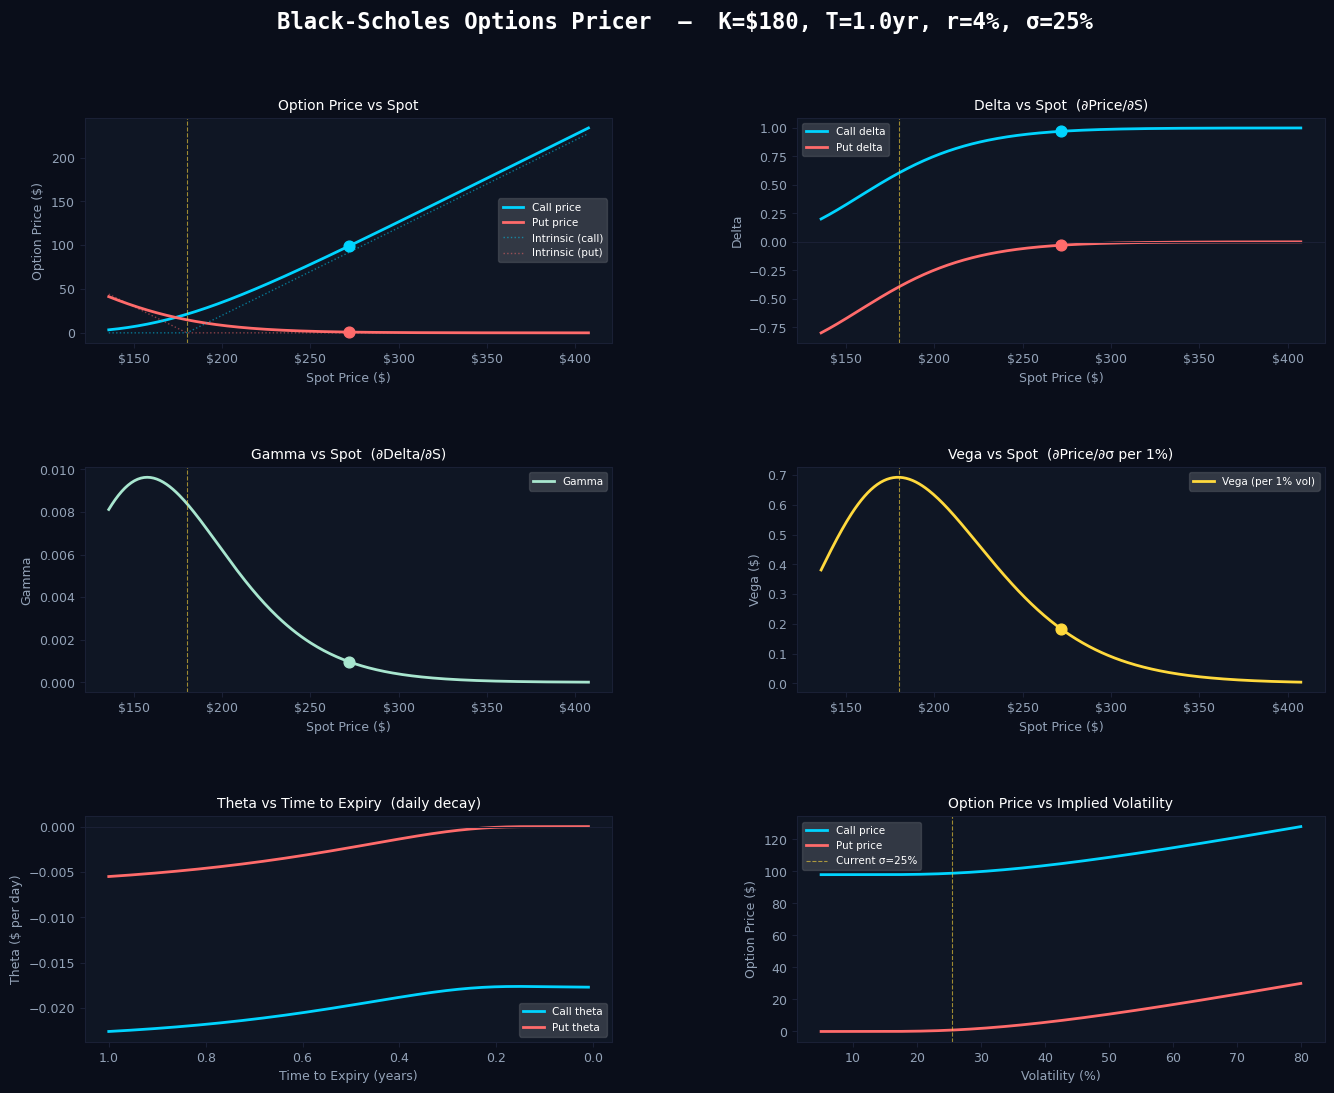

In [9]:
def main() -> None:
    global S, σ

    print(f"Fetching data for {TICKER}...")
    σ, S = estimate_sigma(TICKER, START_DATE, END_DATE)

    # 2. Print full summary
    print_summary(S, K, T, r, σ)

    # 3. Implied volatility demo
    call_price = bs_call(S, K, T, r, σ)
    iv = implied_volatility(call_price, S, K, T, r, "call")
    print(f"\n  Implied Vol demo:")
    print(f"    BS call price at σ={σ:.2%}  : ${call_price:.4f}")
    print(f"    IV recovered from that price : {iv:.2%}  ← should equal σ")

    # 4. Plot
    print("\nGenerating dashboard...")
    plot_dashboard(S, K, T, r, σ)


if __name__ == "__main__":
    main()